100%|██████████| 9.91M/9.91M [00:00<00:00, 11.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 343kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.34MB/s]


Epoch:1, Loss:0.9242
Epoch:2, Loss:0.9262
Epoch:3, Loss:0.9292
Epoch:4, Loss:0.9252
Epoch:5, Loss:0.9254
Epoch:6, Loss:0.9244
Epoch:7, Loss:0.9243
Epoch:8, Loss:0.9259
Epoch:9, Loss:0.9328
Epoch:10, Loss:0.9251
Silhouette Score: 0.5130
Davies-Bouldin Index: 0.5261
Calinski-Harabasz Index: 315518.5625


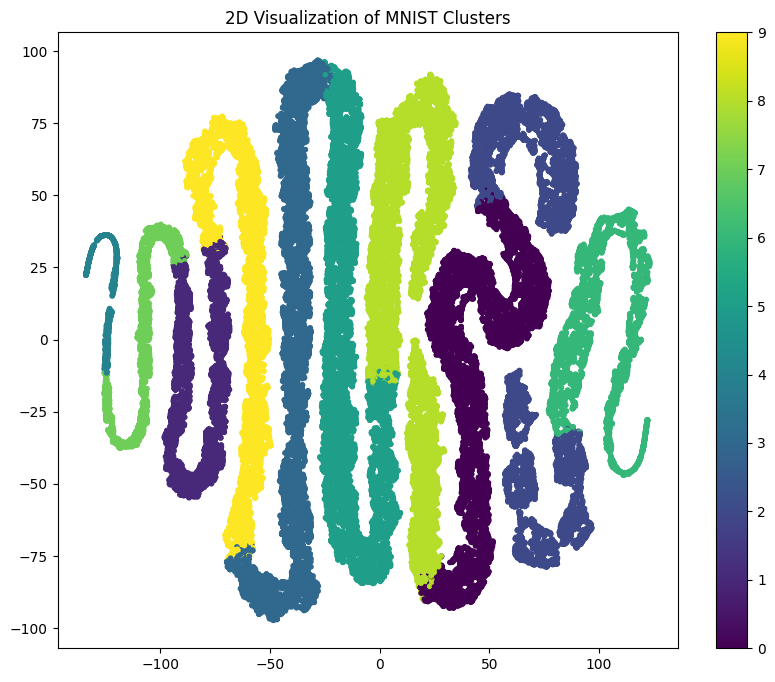

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from sklearn.cluster import KMeans
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# 1. Define the Autoencoder Model [cite: 11, 12, 13, 14]
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, encoding_dim)  # Latent space [cite: 12]
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid()  # Output pixels are 0-1
        )

    def forward(self, x):
        encoding = self.encoder(x)
        reconstruction = self.decoder(encoding)
        return reconstruction, encoding

# 2. Load and Preprocess the MNIST Dataset [cite: 5, 7, 8]
input_dim = 28 * 28  # MNIST images are 28x28
encoding_dim = 64  # Latent space dimension [cite: 20, 21]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
mnist_loader = DataLoader(mnist_dataset, batch_size=256, shuffle=True)

# 3. Initialize the Model, Loss Function, and Optimizer [cite: 32, 33, 34]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Use GPU if available

model = Autoencoder(input_dim, encoding_dim).to(device)
criterion = nn.MSELoss() # Reconstruction loss [cite: 13]
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Train the Autoencoder [cite: 22, 23, 24]
epochs = 10
for epoch in range(epochs):
    for data, _ in mnist_loader:
        data = data.view(-1, input_dim).to(device)  # Flatten the images
        optimizer.zero_grad()
        reconstruction, _ = model(data)
        loss = criterion(reconstruction, data)
        loss.backward()
        optimizer.step()
    print(f'Epoch:{epoch + 1}, Loss:{loss.item():.4f}')

# 5. Generate Embeddings for Clustering [cite: 10, 21]
model.eval() # Set the model to evaluation mode
embeddings = []
with torch.no_grad():
    for data, _ in mnist_loader:
        data = data.view(-1, input_dim).to(device)
        _, encoding = model(data)
        embeddings.append(encoding.cpu().numpy())

embeddings = np.concatenate(embeddings)  # Concatenate all embeddings

# 6. Apply K-Means Clustering [cite: 21, 25]
n_clusters = 10  # MNIST has 10 digits
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(embeddings)
cluster_labels = kmeans.labels_

# 7. Evaluate Clustering Performance [cite: 3, 25]
silhouette_avg = silhouette_score(embeddings, cluster_labels)
db_index = davies_bouldin_score(embeddings, cluster_labels)
ch_index = calinski_harabasz_score(embeddings, cluster_labels)

print(f"Silhouette Score: {silhouette_avg:.4f}")
print(f"Davies-Bouldin Index: {db_index:.4f}")
print(f"Calinski-Harabasz Index: {ch_index:.4f}")

#8. Visualize
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Reduce dimensionality of embeddings for visualization
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

# Create scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=cluster_labels, cmap='viridis', s=10)
plt.colorbar(scatter)
plt.title('2D Visualization of MNIST Clusters')
plt.show()

Epoch 1, Loss: 0.9346
Epoch 2, Loss: 0.9254
Epoch 3, Loss: 0.9254
Epoch 4, Loss: 0.9254
Epoch 5, Loss: 0.9254
Epoch 6, Loss: 0.9254
Epoch 7, Loss: 0.9254
Epoch 8, Loss: 0.9254
Epoch 9, Loss: 0.9254
Epoch 10, Loss: 0.9254


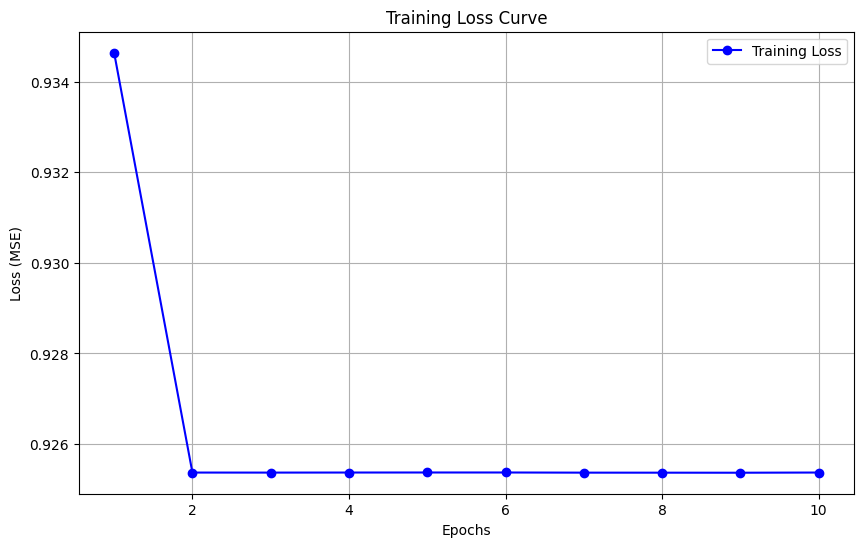

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Example model, DataLoader, and training loop
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoding = self.encoder(x)
        reconstruction = self.decoder(encoding)
        return reconstruction, encoding

# Load MNIST dataset as an example (adjust this if other dataset is used)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Model initialization
input_dim = 784  # MNIST images 28x28
latent_dim = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder(input_dim, latent_dim).to(device)

# Loss and optimizer
criterion = nn.MSELoss()  # Reconstruction loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop to capture the loss for each epoch
epochs = 10
training_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for data, _ in train_loader:
        data = data.view(-1, input_dim).to(device)  # Flatten the images
        optimizer.zero_grad()
        reconstruction, _ = model(data)
        loss = criterion(reconstruction, data)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    training_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# Plot the training loss curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), training_losses, marker='o', linestyle='-', color='b', label='Training Loss')
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.legend()
plt.show()
